# PTB Diagnostic Database Analysis

## Setup

### Packages

Upgrading some packages requires restarting the Colab runtime.
Check that they are installed and up to date to avoid having to restart later.

**Assignment 2 changes:** this notebook now classifies log-spectrogram *images* via
transfer learning instead of hand-crafted features. The demographic-only baseline
section and the spectrogram-summary-statistics + classical-ML section were removed
as no longer needed; a `# edited:` or `# NEW:` comment marks every change/addition.

In [1]:
import sys
if "google.colab" in sys.modules:
    get_ipython().system("pip install --upgrade ydata_profiling matplotlib torchmetrics lightgbm")

In [2]:
!{sys.executable} -m pip install gdown pandas wfdb scikit-learn torch torchvision

In [3]:
!{sys.executable} -m pip install scikit-learn plotly lightgbm

### Data

In [4]:
PATH = "ptb-diagnostic-ecg-database-1.0.0"
PTB_GDRIVE_FILE_ID = "1U9ssvNY18lgWnrsRTZ3wu2G9l4ceujLS"

In [5]:
import os
local_path = os.path.join("..", "data", "ecg", PATH)
if os.path.isdir(local_path):
    !{sys.executable} -m pip install numpy
    PATH = local_path
elif not os.path.isdir(PATH):
    import gdown
    import zipfile
    zip_name = f"{PATH}.zip"
    gdown.download(id=PTB_GDRIVE_FILE_ID, output=zip_name, quiet=False)
    with zipfile.ZipFile(zip_name) as zf:
        zf.extractall()

## Preprocessing

### Read records

In [6]:
records_path = os.path.join(PATH, "RECORDS")

In [7]:
import pandas as pd
records_df = pd.read_csv(records_path, header=None, names=["name"])
records_df.head()


,name
0,patient001/s0010_re
1,patient001/s0014lre
2,patient001/s0016lre
3,patient002/s0015lre
4,patient003/s0017lre


In [8]:
records_df["patient"] = records_df["name"].apply(lambda x: x.split("/")[0])
records_df["id"] = records_df["name"].apply(lambda x: x.split("/")[-1])
records_df["ending"] = records_df["id"].apply(lambda x: x[-3:])
records_df["id"] = records_df["id"].apply(lambda x: x[:-3])
records_df.head()

,name,patient,id,ending
0,patient001/s0010_re,patient001,s0010,_re
1,patient001/s0014lre,patient001,s0014,lre
2,patient001/s0016lre,patient001,s0016,lre
3,patient002/s0015lre,patient002,s0015,lre
4,patient003/s0017lre,patient003,s0017,lre


In [9]:
if "google.colab" in sys.modules:
    get_ipython().system("pip install wfdb")

In [10]:
import wfdb

In [11]:
from tqdm.auto import tqdm
all_signals = []
all_fields = []
for record_name_ in tqdm(records_df["name"]):
    record_path = os.path.join(PATH, record_name_)
    signals, fields = wfdb.rdsamp(record_path)
    all_signals.append(signals)
    all_fields.append(fields)
records_df["signals"] = all_signals
records_df["fields"] = all_fields
records_df

/opt/homebrew/Cellar/jupyterlab/4.6.3/libexec/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|████████████████████████████████████████| 549/549 [00:09<00:00, 58.70it/s]


,name,patient,id,ending,signals,fields
0,patient001/s0010_re,patient001,s0010,_re,"[[-0.2445, -0.229, 0.0155, 0.237, -0.13, -0.10...","{'fs': 1000, 'sig_len': 38400, 'n_sig': 15, 'b..."
1,patient001/s0014lre,patient001,s0014,lre,"[[-0.474, -0.0595, 0.415, 0.267, -0.445, 0.178...","{'fs': 1000, 'sig_len': 115200, 'n_sig': 15, '..."
2,patient001/s0016lre,patient001,s0016,lre,"[[0.254, 0.7535, 0.499, -0.5035, -0.1225, 0.62...","{'fs': 1000, 'sig_len': 115200, 'n_sig': 15, '..."
3,patient002/s0015lre,patient002,s0015,lre,"[[0.2735, -0.035, -0.308, -0.119, 0.291, -0.17...","{'fs': 1000, 'sig_len': 115200, 'n_sig': 15, '..."
4,patient003/s0017lre,patient003,s0017,lre,"[[-0.6195, -0.9435, -0.3235, 0.782, -0.1475, -...","{'fs': 1000, 'sig_len': 115200, 'n_sig': 15, '..."
...,...,...,...,...,...,...
544,patient292/s0555_re,patient292,s0555,_re,"[[-0.5035, 1.6195, 2.124, -0.558, -1.314, 1.87...","{'fs': 1000, 'sig_len': 120012, 'n_sig': 15, '..."
545,patient292/s0556_re,patient292,s0556,_re,"[[0.8055, -0.2945, -1.1, -0.2555, 0.9535, -0.6...","{'fs': 1000, 'sig_len': 120012, 'n_sig': 15, '..."
546,patient293/s0557_re,patient293,s0557,_re,"[[-1.1685, -1.672, -0.5035, 1.42, -0.333, -1.0...","{'fs': 1000, 'sig_len': 120012, 'n_sig': 15, '..."
547,patient293/s0558_re,patient293,s0558,_re,"[[0.6085, 0.134, -0.4735, -0.371, 0.541, -0.16...","{'fs': 1000, 'sig_len': 120012, 'n_sig': 15, '..."


### Expand features

In [12]:
fields = records_df["fields"][0].keys()
for field in fields:
    records_df[field] = records_df["fields"].apply(lambda x: x[field])
records_df.drop(columns=["fields"], inplace=True)
records_df

,name,patient,id,ending,signals,fs,sig_len,n_sig,base_date,base_time,units,sig_name,comments
0,patient001/s0010_re,patient001,s0010,_re,"[[-0.2445, -0.229, 0.0155, 0.237, -0.13, -0.10...",1000,38400,15,None,None,"[mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, m...","[i, ii, iii, avr, avl, avf, v1, v2, v3, v4, v5...","[age: 81, sex: female, ECG date: 01/10/1990, D..."
1,patient001/s0014lre,patient001,s0014,lre,"[[-0.474, -0.0595, 0.415, 0.267, -0.445, 0.178...",1000,115200,15,None,None,"[mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, m...","[i, ii, iii, avr, avl, avf, v1, v2, v3, v4, v5...","[age: 81, sex: female, ECG date: 17/10/1990, D..."
2,patient001/s0016lre,patient001,s0016,lre,"[[0.254, 0.7535, 0.499, -0.5035, -0.1225, 0.62...",1000,115200,15,None,None,"[mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, m...","[i, ii, iii, avr, avl, avf, v1, v2, v3, v4, v5...","[age: 81, sex: female, ECG date: 18/10/1990, D..."
3,patient002/s0015lre,patient002,s0015,lre,"[[0.2735, -0.035, -0.308, -0.119, 0.291, -0.17...",1000,115200,15,None,None,"[mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, m...","[i, ii, iii, avr, avl, avf, v1, v2, v3, v4, v5...","[age: 58, sex: female, ECG date: 17/10/1990, D..."
4,patient003/s0017lre,patient003,s0017,lre,"[[-0.6195, -0.9435, -0.3235, 0.782, -0.1475, -...",1000,115200,15,None,None,"[mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, m...","[i, ii, iii, avr, avl, avf, v1, v2, v3, v4, v5...","[age: 63, sex: male, ECG date: 18/10/1990, Dia..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
544,patient292/s0555_re,patient292,s0555,_re,"[[-0.5035, 1.6195, 2.124, -0.558, -1.314, 1.87...",1000,120012,15,None,None,"[mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, m...","[i, ii, iii, avr, avl, avf, v1, v2, v3, v4, v5...","[age: 66, sex: male, ECG date: 03/06/1997, Dia..."
545,patient292/s0556_re,patient292,s0556,_re,"[[0.8055, -0.2945, -1.1, -0.2555, 0.9535, -0.6...",1000,120012,15,None,None,"[mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, m...","[i, ii, iii, avr, avl, avf, v1, v2, v3, v4, v5...","[age: 66, sex: male, ECG date: 03/06/1997, Dia..."
546,patient293/s0557_re,patient293,s0557,_re,"[[-1.1685, -1.672, -0.5035, 1.42, -0.333, -1.0...",1000,120012,15,None,None,"[mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, m...","[i, ii, iii, avr, avl, avf, v1, v2, v3, v4, v5...","[age: 75, sex: male, ECG date: 03/06/1997, Dia..."
547,patient293/s0558_re,patient293,s0558,_re,"[[0.6085, 0.134, -0.4735, -0.371, 0.541, -0.16...",1000,120012,15,None,None,"[mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, m...","[i, ii, iii, avr, avl, avf, v1, v2, v3, v4, v5...","[age: 75, sex: male, ECG date: 03/06/1997, Dia..."


In [13]:
import itertools
all_comments = itertools.chain(*records_df["comments"])
all_comment_keys = sorted(set(x.split(":")[0] for x in all_comments))
all_comment_keys

['Acute infarction (localization)',
 'Additional diagnoses',
 'Additional medication',
 'Admission date',
 'Aorta (at rest) (syst/diast)',
 'Aorta (at rest) mean',
 'Cardiac index (at rest)',
 'Cardiac index (load)',
 'Cardiac output (at rest)',
 'Cardiac output (load)',
 'Catheterization date',
 'Chest X-ray',
 'Diagnose',
 'Dosage (lytic agent)',
 'ECG date',
 'Echocardiography',
 'Former infarction (localization)',
 'Hemodynamics',
 'In hospital medication',
 'Infarction date',
 'Infarction date (acute)',
 'Left coronary artery stenoses (RCX)',
 'Left coronary artery stenoses (RIVA)',
 'Left ventricular enddiastolic pressure',
 'Lytic agent',
 'Medication after discharge',
 'Medication pre admission',
 'Number of coronary vessels involved',
 'Peripheral blood Pressure (syst/diast)',
 'Previous infarction (1) date',
 'Previous infarction (2) date',
 'Pulmonary artery pressure (at rest) (mean)',
 'Pulmonary artery pressure (at rest) (syst/diast)',
 'Pulmonary artery pressure (laod) (m

In [14]:
def no_start_whitespace(x: str) -> str:
    return x[1:] if x.startswith(" ") else x
comment_dicts = [
    {comment.split(":")[0]: no_start_whitespace(comment.split(":")[1]) for comment in comments}
    for comments in records_df["comments"]
]
for comment_key in all_comment_keys:
    records_df[comment_key] = [
        comment_dict.get(comment_key, None)
        for comment_dict in comment_dicts
    ]
records_df.drop(columns=["comments"], inplace=True)
records_df.columns

Index(['name', 'patient', 'id', 'ending', 'signals', 'fs', 'sig_len', 'n_sig',
       'base_date', 'base_time', 'units', 'sig_name',
       'Acute infarction (localization)', 'Additional diagnoses',
       'Additional medication', 'Admission date',
       'Aorta (at rest) (syst/diast)', 'Aorta (at rest) mean',
       'Cardiac index (at rest)', 'Cardiac index (load)',
       'Cardiac output (at rest)', 'Cardiac output (load)',
       'Catheterization date', 'Chest X-ray', 'Diagnose',
       'Dosage (lytic agent)', 'ECG date', 'Echocardiography',
       'Former infarction (localization)', 'Hemodynamics',
       'In hospital medication', 'Infarction date', 'Infarction date (acute)',
       'Left coronary artery stenoses (RCX)',
       'Left coronary artery stenoses (RIVA)',
       'Left ventricular enddiastolic pressure', 'Lytic agent',
       'Medication after discharge', 'Medication pre admission',
       'Number of coronary vessels involved',
       'Peripheral blood Pressure (syst/dia

### Data wrangling

Remove trivial features.

In [15]:
for column in records_df.columns:
    if column == "signals":
        continue
    try:
        column_uniques = records_df[column].unique()
    except TypeError:
        column_uniques = records_df[column].drop_duplicates()
    if len(column_uniques) == 1:
        print(f"{column} is always {column_uniques[0]}, deleting")
        records_df.drop(columns=[column], inplace=True)

fs is always 1000, deleting
n_sig is always 15, deleting
base_date is always None, deleting
base_time is always None, deleting
units is always ['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV'], deleting
sig_name is always ['i', 'ii', 'iii', 'avr', 'avl', 'avf', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'vx', 'vy', 'vz'], deleting
Diagnose is always , deleting
Hemodynamics is always , deleting
Therapy is always , deleting


Transform age to numeric values.

In [16]:
records_df["age"] = pd.to_numeric(records_df["age"], errors="coerce")

Enforce uniform missing format for sex.

In [17]:
records_df.loc[records_df["sex"] == "", "sex"] = "n/a"

Enforce uniform format for smoker.

In [18]:
records_df.rename(columns={"Smoker": "smoker"}, inplace=True)
records_df.loc[records_df["smoker"] == "unknown", "smoker"] = "n/a"

Dates need to be converted from strings to a format which enables calculations.

In [19]:
import datetime
def parse_date(datestr: str) -> datetime.date:
    try:
        if "/" in datestr:
            return datetime.datetime.strptime(datestr, "%d/%m/%Y")
        else:
            return datetime.datetime.strptime(datestr, "%d-%b-%y")
    except ValueError:
        return pd.NaT

In [20]:
records_df["ecg_date"] = records_df["ECG date"].apply(parse_date)
records_df["admission_date"] = records_df["Admission date"].apply(parse_date)
records_df["infarction_date"] = records_df["Infarction date"].apply(parse_date)

Create patient-diagnosis association.

In [21]:
records_df.rename(columns={"Reason for admission": "diagnosis"}, inplace=True)
patient_df = records_df[["patient", "age", "sex", "smoker", "diagnosis"]].drop_duplicates()

In [22]:
diagnosis_counts = patient_df["diagnosis"].value_counts()
diagnosis_counts

diagnosis
Myocardial infarction     148
Healthy control            52
n/a                        22
Cardiomyopathy             15
Bundle branch block        15
Dysrhythmia                14
Hypertrophy                 7
Valvular heart disease      6
Myocarditis                 4
Stable angina               2
Heart failure (NYHA 2)      1
Heart failure (NYHA 3)      1
Heart failure (NYHA 4)      1
Palpitation                 1
Unstable angina             1
Name: count, dtype: int64

## Splits

**Statistics for the test set**

Note: *formally* for the test set one is not allowed even to analyze statistics...
It is however sensible to ignore this constraint when data is limited,
or when special treatment of groups is needed (e.g. stratified sampling).

### Stratified sampling

Stratified sampling over some variables $x_1$, $x_2$, ...
means to perform splits randomly within each subgroup for fixed values (ranges) of the variables.
E.g. divide m/f, age groups 20-30, 30-40, ... and then perform splits randomly.

We will stratify splits over diagnoses to make sure we have some data for all of them
in all training and evaluation sets.
We could stratify folds also over age, sex and smoking habits.
We will refrain from this since the analysis should not be too sensitive to small fluctuations of these features among splits.

We could also stratify over the number of ECGs per patient.
This would help to keep the amount of data really balanced,
and would be very important for studies invloving follow-ups.

**Diagnoses to consider**

Some diagnoses have too little data for a meaningful evaluation.
The absolute minimum required is one sample for train, valid, and test set.
However, estimates with few samples tend not to be very meaningful.
Here we set the cutoff at at least 4 samples in a 34% test set, i.e. 12 in total.

In [23]:
kept_labels = sorted(label for label in diagnosis_counts[diagnosis_counts > 12].index if label != "n/a")
kept_labels

['Bundle branch block',
 'Cardiomyopathy',
 'Dysrhythmia',
 'Healthy control',
 'Myocardial infarction']

### Test set

First, define the patients with the selected diagnoses.

Only keep the patients who have the selected diseases above 12 per disease

In [24]:
selected_patients = patient_df[patient_df["diagnosis"].isin(kept_labels)].reset_index(drop=True)
selected_patients

,patient,age,sex,smoker,diagnosis
0,patient001,81.0,female,no,Myocardial infarction
1,patient002,58.0,female,yes,Myocardial infarction
2,patient003,63.0,male,yes,Myocardial infarction
3,patient004,69.0,male,no,Myocardial infarction
4,patient005,74.0,male,no,Myocardial infarction
...,...,...,...,...,...
239,patient290,60.0,male,n/a,Myocardial infarction
240,patient291,69.0,male,n/a,Myocardial infarction
241,patient292,66.0,male,n/a,Myocardial infarction
242,patient293,75.0,male,n/a,Myocardial infarction


Import the function to perform a dataset split from `scikit-learn`.
Choose a test size of 1/3 and leave the rest of the data for cross-validation.
Fix the seed of the random number generator, so that results are reproducible
and if there are issues with some specific data points they can be tracked down.
Then count the number of patients with each diagnosis in both sets
to make sure everything went right.

In [25]:
from sklearn.model_selection import train_test_split

patients_trainvalid, patients_test = train_test_split(
    selected_patients,
    test_size=0.34,
    stratify=selected_patients["diagnosis"],
    random_state=42,
)

patients_trainvalid["diagnosis"].value_counts()

diagnosis
Myocardial infarction    98
Healthy control          34
Bundle branch block      10
Cardiomyopathy           10
Dysrhythmia               9
Name: count, dtype: int64

In [26]:
patients_test["diagnosis"].value_counts()

diagnosis
Myocardial infarction    50
Healthy control          18
Dysrhythmia               5
Bundle branch block       5
Cardiomyopathy            5
Name: count, dtype: int64

### Cross-validation

The nice tools of `scikit-learn` for folds do not work well with splits by patient...

The data is limited enough that it is worthwhile to use cross-validation.

In [27]:
N_FOLDS = 3

In [28]:
patients_trainvalid = patients_trainvalid.sort_values(by="patient")
patients_trainvalid["fold"] = -1
total = 0
for i, label in enumerate(kept_labels):  # edited: was undefined `labels` in the original notebook, fixed so it runs standalone
    label_df = patients_trainvalid[patients_trainvalid["diagnosis"] == label]
    shuffled_df = label_df.sample(frac=1, random_state=i+1)
    for j in range(N_FOLDS):
        fold_indices = shuffled_df["patient"][j::N_FOLDS].index
        fold = (j + total) % N_FOLDS  # Rotate the number of the fold which gets residual elements
        patients_trainvalid.loc[fold_indices, "fold"] = fold
    total += len(shuffled_df)
patients_trainvalid

,patient,age,sex,smoker,diagnosis,fold
1,patient002,58.0,female,yes,Myocardial infarction,2
5,patient006,62.0,female,yes,Myocardial infarction,0
6,patient007,70.0,male,no,Myocardial infarction,2
7,patient008,60.0,male,yes,Myocardial infarction,1
9,patient010,46.0,male,no,Myocardial infarction,1
...,...,...,...,...,...,...
233,patient283,82.0,male,n/a,Myocardial infarction,2
236,patient287,78.0,female,n/a,Myocardial infarction,1
237,patient288,67.0,male,n/a,Cardiomyopathy,1
238,patient289,69.0,female,n/a,Cardiomyopathy,0


In [29]:
for fold, fold_df in patients_trainvalid.groupby("fold"):
    print(f"Fold {fold}: {len(fold_df)}")
    print(fold_df["diagnosis"].value_counts())

Fold 0: 54
diagnosis
Myocardial infarction    33
Healthy control          11
Bundle branch block       4
Dysrhythmia               3
Cardiomyopathy            3
Name: count, dtype: int64
Fold 1: 54
diagnosis
Myocardial infarction    33
Healthy control          11
Cardiomyopathy            4
Dysrhythmia               3
Bundle branch block       3
Name: count, dtype: int64
Fold 2: 53
diagnosis
Myocardial infarction    32
Healthy control          12
Cardiomyopathy            3
Dysrhythmia               3
Bundle branch block       3
Name: count, dtype: int64


In [30]:
patient_fold_dict = {k: v for k, v in zip(patients_trainvalid["patient"], patients_trainvalid["fold"])}

In [31]:
patient_fold_dict

{'patient002': 2,
 'patient006': 0,
 'patient007': 2,
 'patient008': 1,
 'patient010': 1,
 'patient011': 1,
 'patient013': 2,
 'patient016': 1,
 'patient017': 0,
 'patient018': 0,
 'patient019': 0,
 'patient020': 0,
 'patient021': 0,
 'patient022': 0,
 'patient023': 0,
 'patient024': 2,
 'patient025': 2,
 'patient026': 2,
 'patient029': 1,
 'patient030': 1,
 'patient031': 1,
 'patient032': 1,
 'patient034': 1,
 'patient036': 2,
 'patient038': 2,
 'patient039': 2,
 'patient040': 2,
 'patient043': 1,
 'patient045': 2,
 'patient046': 1,
 'patient049': 0,
 'patient050': 0,
 'patient053': 1,
 'patient054': 0,
 'patient055': 1,
 'patient056': 0,
 'patient057': 0,
 'patient058': 1,
 'patient059': 0,
 'patient060': 0,
 'patient061': 0,
 'patient064': 2,
 'patient066': 0,
 'patient067': 2,
 'patient068': 1,
 'patient069': 2,
 'patient070': 2,
 'patient071': 0,
 'patient073': 0,
 'patient074': 1,
 'patient075': 2,
 'patient076': 2,
 'patient080': 2,
 'patient082': 1,
 'patient083': 0,
 'patient0

## Evaluation

To infer diagnoses from data, there are multiple categorical labels.
The problem can be formulated either as

- multi-class classification, if labels are mutually exclusive;
- multi-label classification, if multiple labels can occur at the same time.

Clearly the latter would be the case for the additional diagnoses,
but the dataset has been created with a single "reason for admission".

### Metrics

Track:

- the confusion matrix, since all other metrics can be computed from it
(if they do not involve a threshold);
- accuracy, as a check since it is the easiest to understand;
- balanced accuracy, the accuracy that would be calculated
if all classes had the same number of samples;
- Matthews correlation coefficient, as a single summary variable.

In [32]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    matthews_corrcoef,
)
metrics = {
    "confusion_matrix": confusion_matrix,
    "accuracy": accuracy_score,
    "balanced_accuracy": balanced_accuracy_score,
    "matthews_corrcoef": matthews_corrcoef,
}

Define a function for evaluation, given input
train/valid sets, features, label, model and metrics.

In [33]:
from typing import Protocol

class ScikitModel(Protocol):
    def fit(self, X, y, sample_weight=None): ...
    def predict(self, X): ...


from typing import Callable

def evaluate(
    Xy_train: pd.DataFrame,
    Xy_valid: pd.DataFrame,
    feature_columns: list[str],
    label_column: str,
    model: ScikitModel,
    metrics: dict[str, Callable],
    class_weights: bool = False,
) -> list[tuple[str, str, float]]:

    X_train = Xy_train[feature_columns]
    X_valid = Xy_valid[feature_columns]
    y_train = Xy_train[label_column]
    y_valid = Xy_valid[label_column]
    sample_weights = None

    if class_weights:
        class_weights_dict = 1 / Xy_train[label_column].value_counts()
        sample_weights = Xy_train[label_column].apply(lambda x: class_weights_dict[x])
    model.fit(X_train, y_train, sample_weights)
    results = []
    y_pred = model.predict(X_train)
    for k, v in metrics.items():
        results.append((k, "train", v(y_true=y_train, y_pred=y_pred)))
    y_pred = model.predict(X_valid)
    for k, v in metrics.items():
        results.append((k, "valid", v(y_true=y_valid, y_pred=y_pred)))
    return results

Define a function to perform evaluation for all folds,
and store the result in a dataframe.

In [34]:
def evaluate_folds(
    Xy: pd.DataFrame,
    fold_column: str = "fold",
    **kwargs,
) -> pd.DataFrame:
    results = []
    folds = sorted(Xy[fold_column].unique())
    for fold in folds:
        bools = Xy[fold_column] == fold
        metric_values = evaluate(
            Xy_train=Xy[~bools], Xy_valid=Xy[bools], **kwargs
        )
        for metric_name, split, value in metric_values:
            results.append((metric_name, fold, split, value))
    return pd.DataFrame(results, columns=("metric", "fold", "split", "value"))

### Dummy baselines

Get a copy of the train/valid data to run the baselines on,
since it will need to be modified.

Start with the dummy models which use no features.

In [35]:
Xy_trainvalid = patients_trainvalid.copy()  # Will need to be modified
feature_columns = []
label_column = "diagnosis"

In [36]:
from sklearn.dummy import DummyClassifier
baselines = ["most_frequent", "stratified", "uniform"]
strategy_results = []
for strategy in baselines:
    model = DummyClassifier(strategy=strategy)
    strategy_result = evaluate_folds(
        Xy=Xy_trainvalid,
        feature_columns=feature_columns,
        label_column=label_column,
        model=model,
        metrics=metrics,
    )
    strategy_result["strategy"] = strategy
    strategy_results.append(strategy_result)
strategy_results = pd.concat(strategy_results)

Graphically display scores.

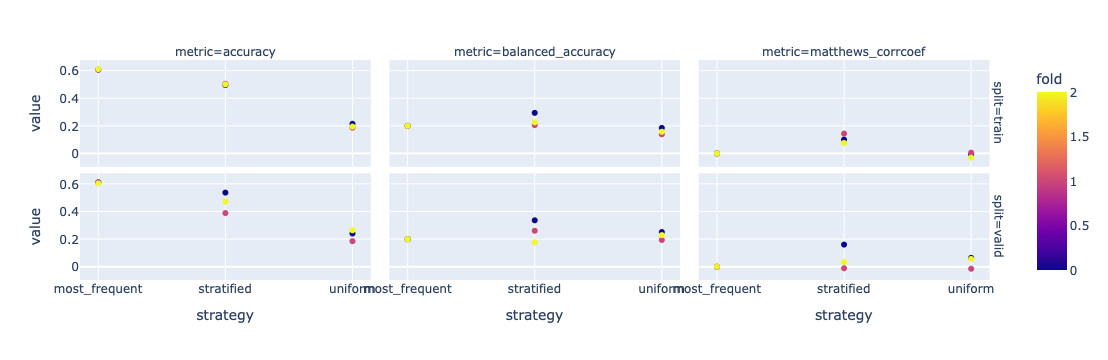

In [37]:
import plotly.express as px
strategy_scores = strategy_results[strategy_results["metric"] != "confusion_matrix"]
px.scatter(strategy_scores, facet_col="metric", facet_row="split", x="strategy", y="value", color="fold")

Observe that

- accuracy gets the highest score just above 60% with the "most frequent" or "popular" model;
- balanced accuracy remains around 20% with more or less fluctuations among folds for all models;
- MCC is around zero as expected for non-informative models.


*(edited: removed the demographic-only "advanced baselines" section below — age/sex/smoking status aren't part of this assignment.)*

In [38]:
import numpy as np

In [39]:
frequency = 10 ** 3
window_length = 2 ** 13
a_record = records_df.iloc[42]
ecg_signals = a_record["signals"]

In [40]:
from scipy.signal import resample_poly
from functools import partial
downsample_factor = 2 ** 3
downsample = partial(resample_poly, up=1, down=downsample_factor)
ecg_downsampled_signals = downsample(ecg_signals)
downsampled_frequency = frequency / downsample_factor
downsampled_signal_i = ecg_downsampled_signals[: (window_length // downsample_factor), 0]

In [41]:
def augment(x: np.ndarray, start: float, window_length: int) -> np.ndarray:
    start_el = int(start * (len(x) - window_length))
    stop_el = start_el + window_length
    return x[start_el:stop_el, :]


## Model on spectrogram

### Spectrogram example

Use the library `scipy` to compute the spectrogram.
API documentation can be found [here](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.spectrogram.html).

Note that the choice of window size and hopping parameter are crucial.

In [42]:
from scipy.signal import spectrogram

Choose a window of roughly half a second, and frequent hops.
"Hann" window is an option frequently used for ECGs.

In [43]:
nperseg = 2 ** 6  # 64 samples at 125 Hz give about 1/2 a second
nhop = 2 ** 2  # Steps are 4 samples at 125 Hz, 0.03s (similar to ECG paper)
noverlap = nperseg - nhop
nfft = 2 ** 7
window = "hann"

Compute and plot the log of the spectrogram.

In [44]:
f_spectrogram, t_spectrogram, a_spectrogram = spectrogram(
    downsampled_signal_i,
    nperseg=nperseg,
    noverlap=noverlap,
    nfft=nfft,
    window=window,
    fs=downsampled_frequency,
)
a_spectrogram.shape

(65, 241)

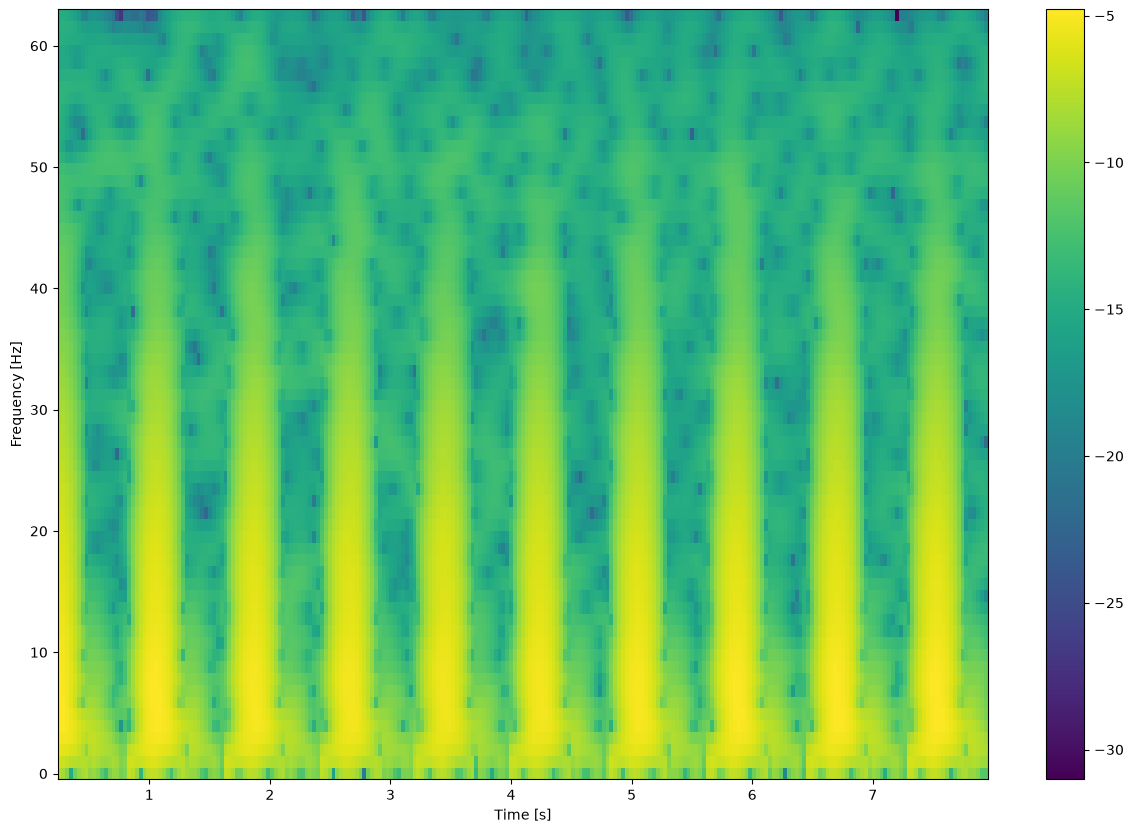

In [45]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 10))
plt.pcolormesh(t_spectrogram, f_spectrogram, np.log(a_spectrogram))
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.show()

Heartbeats are fairly visible, and span up to different frequencies.
P and T waves are confined to the lower part of the spectrum.

*(edited: removed the hand-crafted summary-statistic features + classical-ML section below — superseded by the spectrogram-image transfer-learning approach.)*

### From a single spectrogram to a reusable function

Wrap the computation used for the single example above into a function,
so it can be called once per sample inside the PyTorch `Dataset` below.

In [46]:
# new: log-spectrogram helper wrapping the lecture's single-recording spectrogram code. The value clamp now happens BEFORE the log instead of repairing afterwards.
# Avoids division by zero RuntimeWarning on every batch once flat ECG leads.

def compute_log_spectrogram(signal_1d: np.ndarray, fs: float) -> np.ndarray:
    _, _, a_spec = spectrogram(
        signal_1d,
        nperseg=nperseg,
        noverlap=noverlap,
        nfft=nfft,
        window=window,
        fs=fs,
    )
    return np.log(np.maximum(a_spec, np.finfo(float).eps))


### Dataset and DataLoader

Map each of the 5 diagnoses selected earlier (`kept_labels`) to a class index,
then build a `Dataset` that, for one record, crops a window (`augment`), downsamples it,
computes its log-spectrogram (`compute_log_spectrogram`), and turns it into a
3-channel image sized for an ImageNet-pretrained backbone.

In [47]:
# new: Dataset/DataLoader adapted to produce log-spectrogram IMAGES instead of raw waveforms.
#      It reuses compute_log_spectrogram() the same function that produced the spectrogram for one single recording.

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF


diagnosis2class = {label: i for i, label in enumerate(kept_labels)}

# new: three distinct leads are stacked as the three image channels, so the pretrained RGB backbone receives three genuinely different views rather than one lead copied 3x.
LEADS = (0, 1, 6)

class ECGSpectrogramDataset(Dataset):
    def __init__(self, df: pd.DataFrame, image_size: int = 224, train: bool = False, rng_seed: int = 0):
        self.df = df.reset_index(drop=True)
        self.image_size = image_size
        self.train = train
        self.rng = np.random.default_rng(rng_seed)

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # edited: reuses the lecture's augment()/downsample() helpers unchanged.
        # A random crop during training, a fixed centre crop for valid/test.
        start = self.rng.uniform(0, 1) if self.train else 0.5
        windowed = augment(row["signals"], start, window_length)
        ds = downsample(windowed)

        channels = []
        for lead in LEADS:
            log_spec = compute_log_spectrogram(ds[:, lead], downsampled_frequency)
            ch = torch.as_tensor(log_spec, dtype=torch.float32)
            # new: per-channel standardisation, then resize to the 224x224 the
            # ImageNet-pretrained backbone expects.
            channels.append((ch - ch.mean()) / (ch.std() + 1e-6))

        image = torch.stack(channels, dim=0)
        image = TF.resize(image, [self.image_size, self.image_size], antialias=True)
        return image, diagnosis2class[row["diagnosis"]]


## Creating the training, validation and testing dataset splits.

In [48]:
# edited: the patient-level splits are unchanged from the lecture notebook, but the datasets/loaders below now build ECGSpectrogramDataset instead of the raw-waveform dataset.
train_df = records_df[records_df["patient"].isin(
    patients_trainvalid.loc[patients_trainvalid["fold"] != 0, "patient"])].reset_index(drop=True)

valid_df = records_df[records_df["patient"].isin(
    patients_trainvalid.loc[patients_trainvalid["fold"] == 0, "patient"])].reset_index(drop=True)

test_df = records_df[records_df["patient"].isin(patients_test["patient"])].reset_index(drop=True)

# new: only the training set draws random crops; valid/test use a fixed centre crop so their spectrograms are deterministic and the metrics are reproducible.
train_dataset = ECGSpectrogramDataset(train_df, train=True)
valid_dataset = ECGSpectrogramDataset(valid_df, train=False)
test_dataset = ECGSpectrogramDataset(test_df, train=False)

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


### Data overview (new)

How many records of each diagnosis end up in each split, and what the model actually sees for each class.

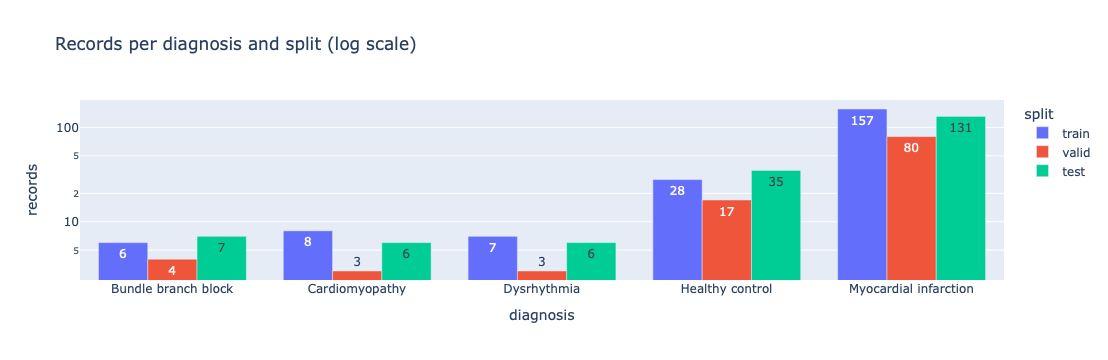

In [49]:
# new: number of ECG records per diagnosis in each split. Shows how dominant the myocardial infarction is.
split_counts = pd.concat([
    train_df["diagnosis"].value_counts().rename("train"),
    valid_df["diagnosis"].value_counts().rename("valid"),
    test_df["diagnosis"].value_counts().rename("test"),
], axis=1).fillna(0).astype(int).reindex(kept_labels)
split_long = split_counts.reset_index(names="diagnosis").melt(id_vars="diagnosis", var_name="split", value_name="records")
px.bar(split_long, x="diagnosis", y="records", color="split", barmode="group", text="records",
       log_y=True, title="Records per diagnosis and split (log scale)")

### Load a pretrained image classifier

Download a pretrained ResNet-18 and run it on a single spectrogram image
to confirm the pipeline works end-to-end before touching the head.

In [50]:
# new: Download a pre-trained image classification model and run it on a single spectrogram with ResNet-18.

import torchvision.models as tv_models

backbone = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)
backbone.eval()

sample_image, sample_label = train_dataset[0]
with torch.no_grad():
    sample_output = backbone(sample_image.unsqueeze(0))
sample_output.shape  # (1, 1000) ImageNet logits - the head still predicts ImageNet classes


torch.Size([1, 1000])

In [51]:
# new: look at what the untouched ImageNet head actually predicts for this spectrogram.
imagenet_classes = tv_models.ResNet18_Weights.IMAGENET1K_V1.meta["categories"]
top5 = torch.softmax(sample_output[0], dim=0).topk(5)
pd.DataFrame({
    "imagenet_class": [imagenet_classes[i] for i in top5.indices.tolist()],
    "probability": top5.values.numpy().round(3),
})

,imagenet_class,probability
0,radiator,0.201
1,shower curtain,0.042
2,window shade,0.041
3,space heater,0.030
4,studio couch,0.029


### Replace the classification head and train

Swap the 1000-way ImageNet head for a 5-way diagnosis head.

*(edited: the backbone is reloaded fresh here, `layer4` is unfrozen alongside the new
head, and the loss is class-weighted. A fully frozen backbone with an unweighted loss
collapses onto the majority class and scores no better than the `most_frequent` dummy
baseline.)*


In [52]:
# new: Replace the 1000-way ImageNet head with a 5-way diagnosis head.

# edited: device selection. The lecture notebook assumed CUDA; this uses Apple Silicon's MPS backend, since torch.cuda.is_available() is always False on a MacBook.

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(device)

# new: the backbone is reloaded from scratch here rather than reusing the backbone object above.
model = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False
model.fc = torch.nn.Linear(model.fc.in_features, len(kept_labels))

for param in model.layer4.parameters():
    param.requires_grad = True

model.to(device)

# new: discriminative learning rates
optimizer = torch.optim.Adam([
    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(), "lr": 1e-3},
])

# new: class-weighted loss. Myocardial infarction is >70% of the training records, so an 
#      unweighted CrossEntropyLoss is minimised by always predicting the majority class.

train_labels = train_df["diagnosis"].map(diagnosis2class).values
class_counts = np.bincount(train_labels, minlength=len(kept_labels))
assert (class_counts > 0).all(), f"a class is missing from the training split: {class_counts}"
class_weights = torch.tensor(
    class_counts.sum() / (len(class_counts) * class_counts), dtype=torch.float32
).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

print("train samples per class:", dict(zip(kept_labels, class_counts)))
print("class weights:", class_weights.cpu().numpy().round(3))


mps
train samples per class: {'Bundle branch block': np.int64(6), 'Cardiomyopathy': np.int64(8), 'Dysrhythmia': np.int64(7), 'Healthy control': np.int64(28), 'Myocardial infarction': np.int64(157)}
class weights: [6.867 5.15  5.886 1.471 0.262]


In [53]:
# edited: the lecture's training loop, adapted for the spectrogram-image model.
from tqdm.auto import tqdm, trange

N_EPOCHS = 20

# edited: the model stays in eval() mode for the whole loop. eval() does not stop
# gradients, it only tells BatchNorm to use the pretrained running statistics instead of recomputing them per batch.

model.eval()

# new: track validation balanced accuracy every epoch and keep the best weights.

history = []
best_bacc = -1.0
best_state = None

for epoch in trange(N_EPOCHS, desc="epochs"):
    train_loss = 0.0
    y_true_train, y_pred_train = [], []
    for images, batch_labels in train_loader:
        images, batch_labels = images.to(device), batch_labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
        y_pred_train.extend(outputs.argmax(dim=-1).detach().cpu().numpy())  
        y_true_train.extend(batch_labels.cpu().numpy())
    train_loss /= len(train_dataset)
    train_bacc = balanced_accuracy_score(y_true=y_true_train, y_pred=y_pred_train)

    valid_loss = 0.0
    y_true_valid, y_pred_valid = [], []
    with torch.no_grad():
        for images, batch_labels in valid_loader:
            images, batch_labels = images.to(device), batch_labels.to(device)
            outputs = model(images)
            valid_loss += criterion(outputs, batch_labels).item() * images.size(0)
            y_pred_valid.extend(outputs.argmax(dim=-1).cpu().numpy())
            y_true_valid.extend(batch_labels.cpu().numpy())
    valid_loss /= len(valid_dataset)
    valid_bacc = balanced_accuracy_score(y_true=y_true_valid, y_pred=y_pred_valid)

    if valid_bacc > best_bacc:
        best_bacc = valid_bacc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    history.append((epoch, train_loss, valid_loss, train_bacc, valid_bacc))
    print(
        f"epoch {epoch:2d}: train_loss={train_loss:.4f} "
        f"valid_loss={valid_loss:.4f} train_balanced_acc={train_bacc:.4f} "
        f"valid_balanced_acc={valid_bacc:.4f}"
    )

# edited: restore the best epoch rather than whatever the last epoch happened to be.
model.load_state_dict(best_state)
print(f"\nrestored best epoch - validation balanced accuracy {best_bacc:.4f}")


epochs:   5%|█▊                                 | 1/20 [00:14<04:31, 14.31s/it]

epoch  0: train_loss=1.6874 valid_loss=1.4499 train_balanced_acc=0.2503 valid_balanced_acc=0.3156


epochs:  10%|███▌                               | 2/20 [00:18<02:34,  8.58s/it]

epoch  1: train_loss=1.4393 valid_loss=1.4043 train_balanced_acc=0.3057 valid_balanced_acc=0.3830


epochs:  15%|█████▎                             | 3/20 [00:23<01:53,  6.67s/it]

...

epoch 17: train_loss=0.4168 valid_loss=1.7586 train_balanced_acc=0.8481 valid_balanced_acc=0.4184


epochs:  95%|████████████████████████████████▎ | 19/20 [01:15<00:03,  3.22s/it]

epoch 18: train_loss=0.4381 valid_loss=1.2068 train_balanced_acc=0.8907 valid_balanced_acc=0.2499


epochs: 100%|██████████████████████████████████| 20/20 [01:18<00:00,  3.94s/it]

epoch 19: train_loss=0.1922 valid_loss=1.8013 train_balanced_acc=0.9539 valid_balanced_acc=0.2581

restored best epoch - validation balanced accuracy 0.4299


### Evaluation
Using the previously trained model evaluate based on accuracy, balanced accuracy, matthews coefficient and confusion matrix

In [54]:
import pandas as pd
history_df = pd.DataFrame(history, columns=["epoch", "train_loss", "valid_loss", "train_balanced_acc", "valid_balanced_acc"])  # edited: + train_balanced_acc
history_df.to_csv("training_history.csv", index=False)
history_df.tail()

,epoch,train_loss,valid_loss,train_balanced_acc,valid_balanced_acc
15,15,0.145383,2.226342,0.912534,0.251324
16,16,0.283790,1.683755,0.931498,0.330147
17,17,0.416779,1.758596,0.848104,0.418382
18,18,0.438144,1.206834,0.890689,0.249853
19,19,0.192173,1.801309,0.953867,0.258088


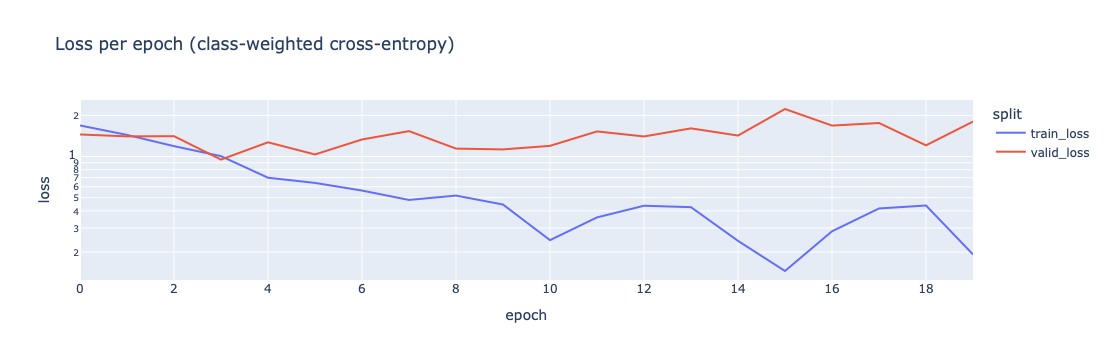

In [55]:
# new: loss per epoch, training vs validation.

loss_long = history_df.melt(
    id_vars="epoch",
    value_vars=["train_loss", "valid_loss"],
    var_name="split",
    value_name="loss",
)
fig_loss = px.line(
    loss_long,
    x="epoch",
    y="loss",
    color="split",
    log_y=True,
    title="Loss per epoch (class-weighted cross-entropy)",
)
fig_loss.show()

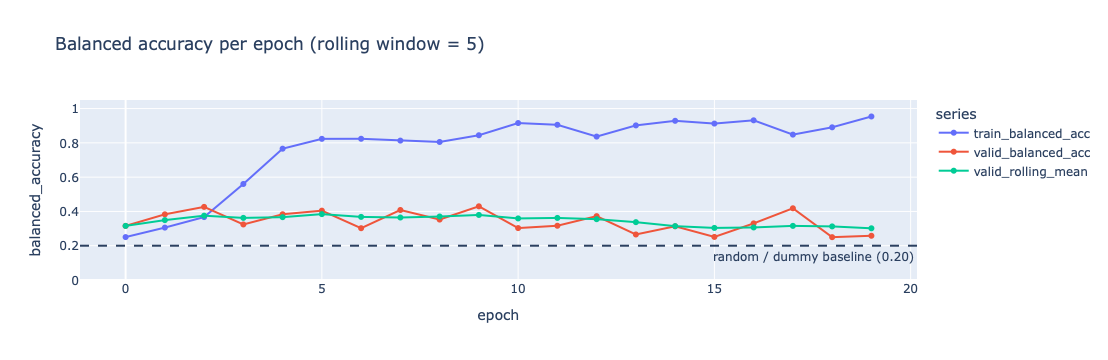

In [56]:
# new: balanced accuracy per epoch for train and validation, plus a rolling mean of validation.
ROLLING_WINDOW = 5
acc_df = history_df[["epoch", "train_balanced_acc", "valid_balanced_acc"]].copy()
acc_df["valid_rolling_mean"] = acc_df["valid_balanced_acc"].rolling(ROLLING_WINDOW, min_periods=1).mean()
acc_long = acc_df.melt(
    id_vars="epoch",
    value_vars=["train_balanced_acc", "valid_balanced_acc", "valid_rolling_mean"],
    var_name="series",
    value_name="balanced_accuracy",
)
fig_acc = px.line(
    acc_long,
    x="epoch",
    y="balanced_accuracy",
    color="series",
    markers=True,
    title=f"Balanced accuracy per epoch (rolling window = {ROLLING_WINDOW})",
)

fig_acc.add_hline(
    y=0.2,
    line_dash="dash",
    annotation_text="random / dummy baseline (0.20)",
    annotation_position="bottom right",
)
fig_acc.update_yaxes(range=[0, 1.05])
fig_acc.show()

In [57]:
# edited: reuse the test_df built above instead of recomputing the test split.
records_test = test_df

In [58]:
# edited: The lecture's test-set inference, adapted to the spectrogram test_loader and the transfer-learning model above.
model.eval()
y_true_test = []
y_pred_test = []
y_prob_test = []
with torch.no_grad():
    for images, batch_labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        y_pred_test.extend(outputs.argmax(dim=-1).cpu().numpy())
        y_prob_test.extend(torch.softmax(outputs, dim=-1).cpu().numpy())
        y_true_test.extend(batch_labels.numpy())
y_true_test = np.array(y_true_test)
y_pred_test = np.array(y_pred_test)
y_prob_test = np.array(y_prob_test)


In [59]:
# new: plain accuracy, for comparison against the "most_frequent" dummy baseline.
accuracy_score(y_pred=y_pred_test, y_true=y_true_test)

0.6648648648648648

In [60]:
# edited: reuses the evaluation metrics imported earlier in the notebook.
# Balanced accuracy = the mean of the five per-class recalls, so every diagnosis counts
balanced_accuracy_score(y_pred=y_pred_test, y_true=y_true_test)

0.36446383133406035

In [61]:
# edited: Matthews correlation coefficient, as used for the waveform model.
matthews_corrcoef(y_pred=y_pred_test, y_true=y_true_test)

0.39404036415077864

In [62]:
# edited: confusion matrix on the spectrogram model's test predictions.
confusion_matrix(y_pred=y_pred_test, y_true=y_true_test)

array([[ 0,  1,  3,  3,  0],
       [ 1,  0,  1,  0,  4],
       [ 0,  1,  2,  0,  3],
       [ 0,  1,  1, 27,  6],
       [ 3, 11, 12, 11, 94]])

### Extra evaluation plots for better result visualisation

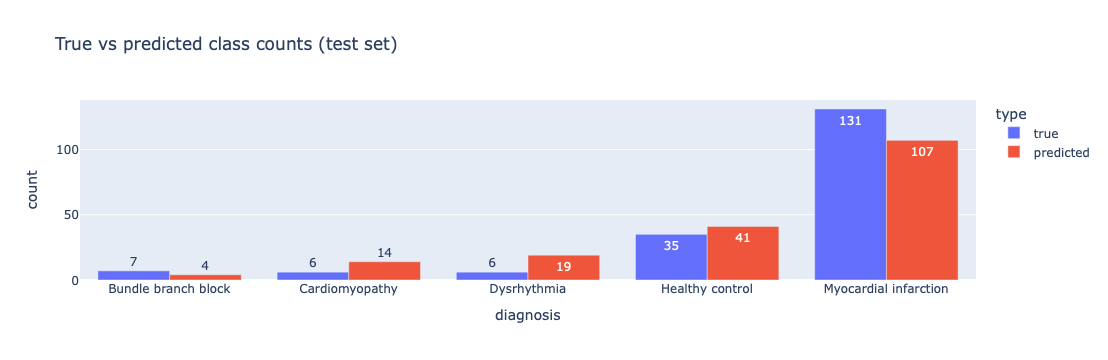

In [63]:
# new: how often each class is predicted vs how often it really occurs.
# Shows whether the model over-predicts the majority class or ignores rare ones.
dist = pd.DataFrame({
    "diagnosis": kept_labels * 2,
    "count": np.concatenate([np.bincount(y_true_test, minlength=len(kept_labels)),
                             np.bincount(y_pred_test, minlength=len(kept_labels))]),
    "type": ["true"] * len(kept_labels) + ["predicted"] * len(kept_labels),
})
px.bar(dist, x="diagnosis", y="count", color="type", barmode="group", text="count",
       title="True vs predicted class counts (test set)")

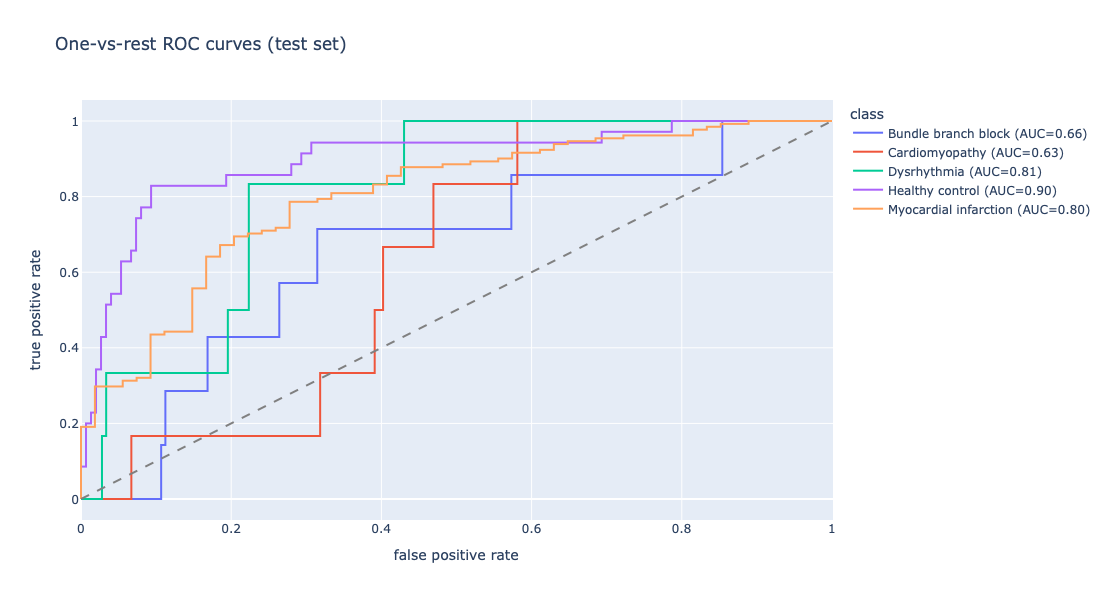

In [64]:
# new: one-vs-rest ROC curve and AUC per diagnosis, using the softmax probabilities.
from sklearn.metrics import roc_curve, roc_auc_score
roc_rows = []
for k, label in enumerate(kept_labels):
    y_bin = (y_true_test == k).astype(int)
    if y_bin.min() == y_bin.max():
        continue
    fpr, tpr, _ = roc_curve(y_bin, y_prob_test[:, k])
    auc = roc_auc_score(y_bin, y_prob_test[:, k])
    roc_rows.append(pd.DataFrame({"fpr": fpr, "tpr": tpr, "class": f"{label} (AUC={auc:.2f})"}))
fig_roc = px.line(pd.concat(roc_rows), x="fpr", y="tpr", color="class",
                  title="One-vs-rest ROC curves (test set)",
                  labels={"fpr": "false positive rate", "tpr": "true positive rate"})
fig_roc.add_shape(type="line", x0=0, y0=0, x1=1, y1=1, line=dict(dash="dash", color="grey"))
fig_roc.update_layout(width=750, height=600)
fig_roc.show()

In [65]:
# The lecture's bootstrap metric dictionary, reused unchanged.
bootstrap_metrics = {
    "accuracy": accuracy_score,
    "balanced_accuracy": balanced_accuracy_score,
    "matthews_corrcoef": matthews_corrcoef,
}


In [66]:
# edited: 10000 bootstrap samples instead of 100, for more stable confidence intervals.
N_BOOTSTRAP = 10000
rng = np.random.default_rng(42)
bootstrap_result = []
patient_column_test = records_test["patient"]
test_patients = np.array(sorted(patient_column_test.unique()))
test_diagnosis = np.array([
    records_test["diagnosis"].iloc[np.argmax(patient_column_test == patient)]
    for patient in test_patients
])
for sample in tqdm(range(N_BOOTSTRAP)):
    y_true_patient = []
    y_pred_patient = []
    weight_patient = []
    for label in kept_labels:
        label_test_patients = test_patients[test_diagnosis == label]
        sampled_patients = rng.choice(
            a=label_test_patients,
            size=len(label_test_patients),
            replace=True,
        )
        for patient in sampled_patients:
            y_true_patient.append(y_true_test[patient_column_test == patient])
            y_pred_patient.append(y_pred_test[patient_column_test == patient])
            weight_patient.append(
                np.full_like(y_true_patient[-1], fill_value=1.0 / len(y_true_patient[-1]), dtype=float)
            )
    y_true_bootstrap = np.concatenate(y_true_patient)
    y_pred_bootstrap = np.concatenate(y_pred_patient)
    weight_bootstrap = np.concatenate(weight_patient)
    for k, v in bootstrap_metrics.items():
        bootstrap_result.append([
            sample,
            k,
            v(y_true=y_true_bootstrap, y_pred=y_pred_bootstrap, sample_weight=weight_bootstrap),
        ])
bootstrap_df = pd.DataFrame(bootstrap_result, columns=["sample", "metric", "value"])
bootstrap_df

100%|███████████████████████████████████| 10000/10000 [01:14<00:00, 135.04it/s]


,sample,metric,value
0,0,accuracy,0.640075
1,0,balanced_accuracy,0.445698
2,0,matthews_corrcoef,0.424071
3,1,accuracy,0.647189
4,1,balanced_accuracy,0.356111
...,...,...,...
29995,9998,balanced_accuracy,0.399111
29996,9998,matthews_corrcoef,0.355336
29997,9999,accuracy,0.686747
29998,9999,balanced_accuracy,0.478667


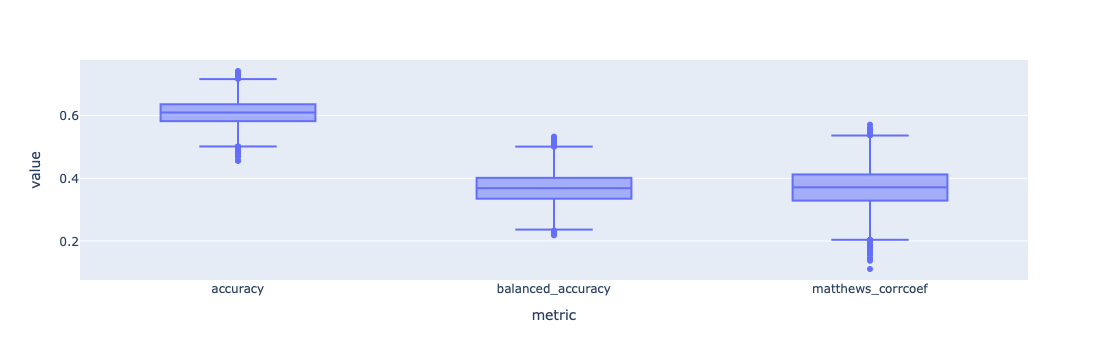

In [67]:
px.box(bootstrap_df, x="metric", y="value")

In [68]:
# new: 95% bootstrap confidence intervals for the test metrics (quoted in the summary).
bootstrap_df.groupby("metric")["value"].agg(
    mean="mean",
    ci_low=lambda v: v.quantile(0.025),
    ci_high=lambda v: v.quantile(0.975),
).round(3)

,mean,ci_low,ci_high
metric,,,
accuracy,0.609,0.529,0.684
balanced_accuracy,0.369,0.277,0.468
matthews_corrcoef,0.370,0.245,0.487


### Multi-seed robustness check

In [69]:
# new: 3-seed robustness check. Everything random during training is seeded per run.
# the setup is identical to the single run above.
import random
from sklearn.metrics import recall_score

SEEDS = [0, 1, 2]


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def build_model():
    m = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)
    for param in m.parameters():
        param.requires_grad = False
    m.fc = torch.nn.Linear(m.fc.in_features, len(kept_labels))  # init depends on the torch seed
    for param in m.layer4.parameters():
        param.requires_grad = True
    m.to(device)
    opt = torch.optim.Adam([
        {"params": m.layer4.parameters(), "lr": 1e-4},
        {"params": m.fc.parameters(), "lr": 1e-3},
    ])
    return m, opt


def predict(m, loader):
    m.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, batch_labels in loader:
            outputs = m(images.to(device))
            y_pred.extend(outputs.argmax(dim=-1).cpu().numpy())
            y_true.extend(batch_labels.numpy())
    return np.array(y_true), np.array(y_pred)


def train_one_seed(seed: int):
    set_seed(seed)
    # seeded random crops (the Dataset already takes rng_seed) and seeded batch shuffling
    seed_train_dataset = ECGSpectrogramDataset(train_df, train=True, rng_seed=seed)
    seed_train_loader = DataLoader(
        seed_train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        generator=torch.Generator().manual_seed(seed),
    )
    m, opt = build_model()
    m.eval()  # same BatchNorm choice as the single run: use the pretrained running statistics

    best_bacc, best_state, seed_history = -1.0, None, []
    for epoch in trange(N_EPOCHS, desc=f"seed {seed}", leave=False):
        train_loss = 0.0
        for images, batch_labels in seed_train_loader:
            images, batch_labels = images.to(device), batch_labels.to(device)
            opt.zero_grad()
            loss = criterion(m(images), batch_labels)
            loss.backward()
            opt.step()
            train_loss += loss.item() * images.size(0)
        y_true_v, y_pred_v = predict(m, valid_loader)
        valid_bacc = balanced_accuracy_score(y_true=y_true_v, y_pred=y_pred_v)
        seed_history.append((seed, epoch, train_loss / len(seed_train_dataset), valid_bacc))
        if valid_bacc > best_bacc:
            best_bacc = valid_bacc
            best_state = {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}

    m.load_state_dict(best_state)
    y_true_t, y_pred_t = predict(m, test_loader)
    return y_true_t, y_pred_t, best_bacc, seed_history

In [70]:
# new: run the 3 seeds and collect test metrics per seed.
seed_rows, seed_recalls, seed_histories = [], [], []
for seed in SEEDS:
    y_true_s, y_pred_s, best_valid_bacc, hist = train_one_seed(seed)
    seed_rows.append({
        "seed": seed,
        "best_valid_balanced_acc": best_valid_bacc,
        "test_accuracy": accuracy_score(y_true_s, y_pred_s),
        "test_balanced_accuracy": balanced_accuracy_score(y_true_s, y_pred_s),
        "test_matthews_corrcoef": matthews_corrcoef(y_true_s, y_pred_s),
    })
    seed_recalls.append(pd.Series(
        recall_score(y_true_s, y_pred_s, labels=range(len(kept_labels)), average=None, zero_division=0),
        index=kept_labels, name=f"seed {seed}",
    ))
    seed_histories.extend(hist)
    print(f"seed {seed}: test balanced acc = {seed_rows[-1]['test_balanced_accuracy']:.3f}, "
          f"MCC = {seed_rows[-1]['test_matthews_corrcoef']:.3f}")

seed_results = pd.DataFrame(seed_rows).set_index("seed")
seed_results.round(3)

seed 0: test balanced acc = 0.387, MCC = 0.433


seed 1: test balanced acc = 0.430, MCC = 0.422


seed 2: test balanced acc = 0.268, MCC = 0.162


,best_valid_balanced_acc,test_accuracy,test_balanced_accuracy,test_matthews_corrcoef
seed,,,,
0,0.372,0.686,0.387,0.433
1,0.447,0.686,0.430,0.422
2,0.345,0.449,0.268,0.162


In [71]:
# new: mean +- std over the 3 seeds.
seed_summary = seed_results.agg(["mean", "std"]).T
seed_summary["mean ± std"] = [f"{m:.3f} ± {s:.3f}" for m, s in zip(seed_summary["mean"], seed_summary["std"])]
seed_summary

,mean,std,mean ± std
best_valid_balanced_acc,0.388007,0.053209,0.388 ± 0.053
test_accuracy,0.607207,0.137316,0.607 ± 0.137
test_balanced_accuracy,0.361839,0.083854,0.362 ± 0.084
test_matthews_corrcoef,0.338916,0.153598,0.339 ± 0.154


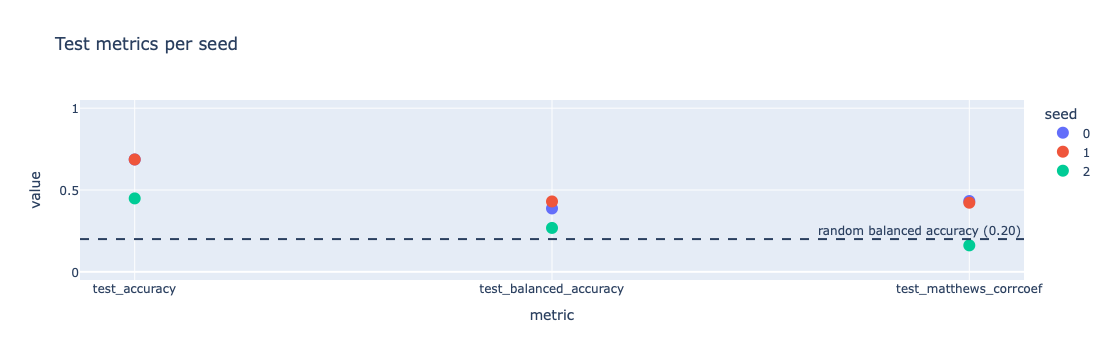

In [72]:
# new: test metrics per seed against the 0.20 random balanced-accuracy baseline.
seed_long = seed_results.reset_index().melt(
    id_vars="seed",
    value_vars=["test_accuracy", "test_balanced_accuracy", "test_matthews_corrcoef"],
    var_name="metric", value_name="value",
)
seed_long["seed"] = seed_long["seed"].astype(str)
fig_seeds = px.scatter(seed_long, x="metric", y="value", color="seed",
                       title="Test metrics per seed")
fig_seeds.update_traces(marker_size=12)
fig_seeds.add_hline(y=0.2, line_dash="dash", annotation_text="random balanced accuracy (0.20)")
fig_seeds.update_yaxes(range=[-0.05, 1.05])
fig_seeds.show()

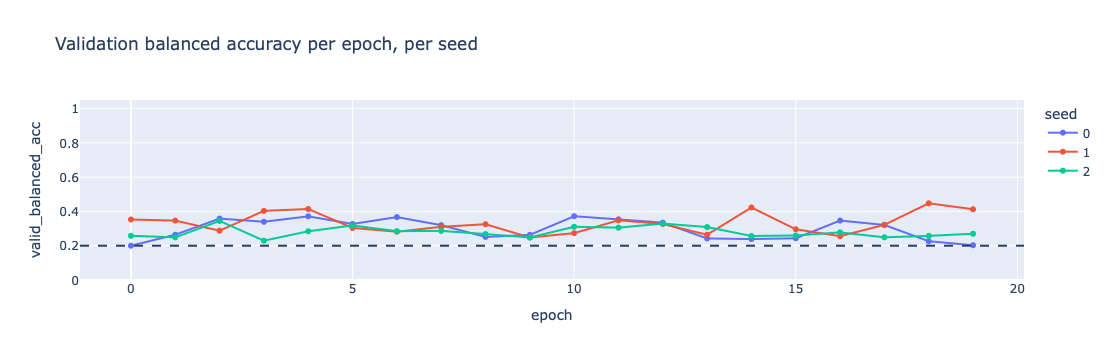

In [73]:
# new: validation balanced accuracy per epoch for each seed
seed_hist_df = pd.DataFrame(seed_histories, columns=["seed", "epoch", "train_loss", "valid_balanced_acc"])
seed_hist_df["seed"] = seed_hist_df["seed"].astype(str)
fig_seed_curves = px.line(seed_hist_df, x="epoch", y="valid_balanced_acc", color="seed", markers=True,
                          title="Validation balanced accuracy per epoch, per seed")
fig_seed_curves.add_hline(y=0.2, line_dash="dash")
fig_seed_curves.update_yaxes(range=[0, 1.05])
fig_seed_curves.show()

### Summary: comparison to baselines and the waveform model

On the test set, the spectrogram combined with ResNet-18 achieves a balanced accuracy of 0.36 and a Matthews correlation coefficient of 0.39, both of which are substantially higher than the dummy baselines that remain at or below 0.20 balanced accuracy and approximately 0 MCC. The model's plain accuracy of 0.66 is only marginally higher than the most_frequent baseline ~0.61, as the baseline predicts myocardial infarction for every record. In contrast, the model correctly identifies 77% of healthy controls and 72% of myocardial infarction records. Across three training seeds, the results exhibit less stability (balanced accuracy 0.36 +- 0.08, MCC 0.34 +- 0.15). The waveform convolutional neural network (CNN) trained during the lecture achieves somewhat higher scores on the same test set, although both values fall within the bootstrap confidence intervals. The two models demonstrate different failures: the waveform model detects most bundle branch block cases (5/7) and myocardial infarction (95%) but only 31% of healthy controls, whereas the spectrogram model performs better on healthy controls but fails to identify bundle branch block and cardiomyopathy, potentially due to its use of only 3 of the 15 leads. For both models, the limited number of training records for rare diagnoses (6–8 records) constrains performance. The substantial gap between training (up to ~0.95) and validation (~0.25–0.43) balanced accuracy indicates strong overfitting, suggesting that performance is primarily limited by sample size rather than input representation.
